# Mamba with Minimal Boilerplate: Focus on the Model

## 1. Configuration

All hyperparameters in one place for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    "seed": 42,  # Random seed for reproducibility

    # Hardware (auto-detected)
    "device": "auto",  # Auto-detect best device (CUDA/MPS/CPU)
    "precision": "auto",  # Auto-detect precision (no AMP on MPS, bf16/16 on CUDA)

    # Data
    "block_size": 128,  # Sequence length for training
    "train_split": 0.8,  # Fraction of data for training

    # Model architecture (MAMBA-STYLE SCALING: smaller model, more training)
    # Mamba paper: 231-2400 tokens/param (vs Chinchilla's 20 tokens/param)
    # Target: 443K params, 500 tokens/param = 221M tokens = 86 epochs
    # Using 40 epochs for practical training time with naive Python SSM loop
    "n_embed": 128,  # Embedding dimension
    "hidden_size": 128,  # Hidden state dimension
    "state_size": 8,  # SSM state dimension
    "n_layers": 4,  # Number of Mamba layers
    "expand_factor": 2,  # Internal expansion factor
    "conv_kernel": 4,  # Convolution kernel size

    # SSM Implementation
    "ssm_backend": "cuda",  # "python" or "cuda" - CUDA is 30-100x faster

    # Training (Mamba-style: ~500 tokens per parameter, not Chinchilla's 20)
    "batch_size": "auto",  # Auto-detect optimal batch size based on hardware
    "max_epochs": 40,  # Mamba-optimal would be ~86, using 40 for speed
    "learning_rate": 3e-4,  # Optimizer learning rate (standard for transformers)
    "early_stop_patience": 10,  # Higher patience for longer training
}

## 2. Initialize Training Environment

Use `init_training()` to set the random seed and auto-detect hardware capabilities. All "auto" fields in the config will be resolved based on available hardware:
- **device**: CUDA > MPS > CPU priority
- **precision**: Automatic mixed precision (AMP) selection - avoids AMP on MPS, uses bf16/16 on CUDA
- **batch_size**: Hardware-optimized based on available memory

In [2]:
from aiml_notebooks.hardware import init_training

# Initialize training environment and resolve auto fields
CONFIG = init_training(CONFIG, verbose=True)
CONFIG

Seed set to 42



🌱 Initializing Training Environment
═══════════════════════════════════════════════════════════════════════════

🎲 Random Seed: 42
   ✓ Seed set using Lightning's seed_everything()

🔍 Detecting hardware for auto-resolution...

🚀 NVIDIA GPU Detected: NVIDIA GeForce RTX 4090
   Compute Capability: 8.9
   Memory: 25.8 GB
   ✓ Ampere+ architecture detected
   ✓ TF32 enabled for matmul and cuDNN

📊 Final Configuration:
   Device: cuda
   Precision: bf16-mixed
   Batch size: 128
   Mixed precision: ✓
   Flash Attention: ✓ (if installed)
   torch.compile: ✓
   Fused optimizer: ✓

⚙️  Resolving 3 'auto' field(s):
   device: auto → cuda
   precision: auto → bf16-mixed
   batch_size: auto → 128

═══════════════════════════════════════════════════════════════════════════
✓ Initialization complete!
═══════════════════════════════════════════════════════════════════════════


/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


{'seed': 42,
 'device': 'cuda',
 'precision': 'bf16-mixed',
 'block_size': 128,
 'train_split': 0.8,
 'n_embed': 128,
 'hidden_size': 128,
 'state_size': 8,
 'n_layers': 4,
 'expand_factor': 2,
 'conv_kernel': 4,
 'ssm_backend': 'cuda',
 'batch_size': 128,
 'max_epochs': 40,
 'learning_rate': 0.0003,
 'early_stop_patience': 10}

## 3. Create Tokenizer

We'll create a character-level tokenizer with a transformers-compatible interface. This makes it trivial to swap in any HuggingFace tokenizer later.

In [3]:
from typing import List, Union

class CharacterTokenizer:
    """
    Character-level tokenizer with transformers-compatible interface.
    
    This class provides the same interface as HuggingFace tokenizers,
    making it easy to swap with any PreTrainedTokenizer.
    """
    
    def __init__(self, text: str):
        # Build vocabulary from text
        self.vocab = sorted(list(set(text)))
        self.vocab_size = len(self.vocab)
        
        # Create mappings
        self._char_to_id = {c: i for i, c in enumerate(self.vocab)}
        self._id_to_char = {i: c for i, c in enumerate(self.vocab)}
    
    def encode(self, text: str) -> List[int]:
        """Convert text to token IDs."""
        return [self._char_to_id[c] for c in text]
    
    def decode(self, token_ids: Union[List[int], int]) -> str:
        """Convert token IDs back to text."""
        if isinstance(token_ids, int):
            return self._id_to_char[token_ids]
        return "".join([self._id_to_char[i] for i in token_ids])
    
    def __call__(self, text: str, **kwargs) -> dict:
        """Tokenize text (transformers-compatible interface)."""
        return {"input_ids": self.encode(text)}
    
    def __len__(self) -> int:
        return self.vocab_size

# Load text and create tokenizer
with open("data/lotr.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

tokenizer = CharacterTokenizer(text)
CONFIG["vocab_size"] = tokenizer.vocab_size

print(f"Loaded {len(text):,} characters")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"First 50 chars: {''.join(tokenizer.vocab[:50])}...")
print(f"\nTokenizer interface test:")
print(f"  encode('hello') = {tokenizer.encode('hello')}")
print(f"  decode([...]) = '{tokenizer.decode(tokenizer.encode('hello'))}'")
print(f"\nTo swap tokenizers, replace CharacterTokenizer with any HuggingFace tokenizer!")

Loaded 3,262,172 characters
Vocabulary size: 73
First 50 chars: 
 !"#&'()*,-./0123456789:;<=>?_`abcdefghijklmnopqr...

Tokenizer interface test:
  encode('hello') = [39, 36, 43, 43, 46]
  decode([...]) = 'hello'

To swap tokenizers, replace CharacterTokenizer with any HuggingFace tokenizer!


### Load and Prepare Data with HuggingFace Datasets

Use the tokenizer to create a dataset of fixed-length sequences.

In [4]:
import torch
from datasets import Dataset

# Tokenize entire text
tokens = tokenizer.encode(text)

# Split into chunks of block_size + 1 (for input and target)
chunk_size = CONFIG["block_size"] + 1
n_chunks = len(tokens) // chunk_size
chunks = [
    tokens[i * chunk_size : (i + 1) * chunk_size]
    for i in range(n_chunks)
]

# Create dataset from chunks (using "input_ids" to match transformers convention)
dataset = Dataset.from_dict({"input_ids": chunks})

# Split into train and validation
split_dataset = dataset.train_test_split(
    test_size=1 - CONFIG["train_split"],
    seed=CONFIG["seed"]
)

print(f"Total chunks: {len(dataset):,}")
print(f"Train: {len(split_dataset['train']):,}")
print(f"Validation: {len(split_dataset['test']):,}")

# Show a sample
sample = split_dataset["train"][0]["input_ids"]
print(f"\nSample input:  '{tokenizer.decode(sample[:-1])}'")
print(f"Sample target: '{tokenizer.decode(sample[1:])}'")
print(f"\nDataset uses 'input_ids' key to match HuggingFace conventions!")

Total chunks: 25,288
Train: 20,230
Validation: 5,058

Sample input:  ' to warm  it; but at 
that time this seemed pleasant. there they took food and drink,  and made as 
good a noon-meal under the o'
Sample target: 'to warm  it; but at 
that time this seemed pleasant. there they took food and drink,  and made as 
good a noon-meal under the op'

Dataset uses 'input_ids' key to match HuggingFace conventions!


### Create DataLoaders

Convert the HuggingFace datasets to PyTorch DataLoaders.

In [5]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Convert batch of token sequences to input/target pairs."""
    tokens = torch.tensor([item["input_ids"] for item in batch])
    x = tokens[:, :-1]  # Input: all but last
    y = tokens[:, 1:]   # Target: all but first (shifted by 1)
    return x, y

train_loader = DataLoader(
    split_dataset["train"],
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    split_dataset["test"],
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)

# Check batch shapes
x_batch, y_batch = next(iter(train_loader))
print(f"Batch input shape: {x_batch.shape}")
print(f"Batch target shape: {y_batch.shape}")
print(f"\nData pipeline complete! HuggingFace datasets handled everything.")

Batch input shape: torch.Size([128, 128])
Batch target shape: torch.Size([128, 128])

Data pipeline complete! HuggingFace datasets handled everything.


## 4. Mamba Model Implementation

**This is the core!** The following cells contain the exact same Mamba implementation from the original notebook. Focus your attention here - this is what makes Mamba work.

### MambaBlock: The Selective SSM Core

This block implements the selective state space mechanism with data-dependent parameters.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MambaBlock(nn.Module):
    """A single Mamba block with selective SSM."""
    
    def __init__(
        self, 
        d_model, 
        d_state=16, 
        expand=2, 
        conv_kernel=4,
        ssm_backend="cuda"
    ):
        super().__init__()

        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand  # Expanded dimension
        self.conv_kernel = conv_kernel
        self.ssm_backend = ssm_backend
                
        # 1. Input projection (to 2*d_inner for x and z)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        
        # 2. Convolution (adds local context within sequence)
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=conv_kernel,
            padding=conv_kernel - 1,
            groups=self.d_inner  # Depthwise convolution
        )
        
        # 3. SSM parameters
        # A: Transition matrix (S4D-Lin initialization)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))  # Log space for stability
        
        # D: Skip connection parameter (used by CUDA implementation)
        self.D = nn.Parameter(torch.ones(self.d_inner))
        
        # 4. Python version: Projection to compute B, C, Δ (scalar delta)
        self.x_proj = nn.Linear(
            self.d_inner,
            d_state * 2 + 1,  # B (d_state) + C (d_state) + Δ (1)
            bias=False
        )
        
        # 5. CUDA version: Separate projections for per-channel delta
        self.dt_proj = nn.Linear(self.d_inner, self.d_inner, bias=True)
        self.B_proj = nn.Linear(self.d_inner, d_state, bias=False)
        self.C_proj = nn.Linear(self.d_inner, d_state, bias=False)
        
        # 6. Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def _preprocess_common(self, x):
        """
        Shared preprocessing: input projection, conv, activation.
        
        Returns:
            x_conv: (B, T, d_inner) - convolved and activated input
            z: (B, T, d_inner) - gate values
        """
        B, T, _ = x.shape
        
        # Input projection and split
        x_and_z = self.in_proj(x)  # (B, T, 2*d_inner)
        x, z = x_and_z.chunk(2, dim=-1)  # Each: (B, T, d_inner)
        
        # Depthwise convolution
        x_conv = x.transpose(1, 2)  # (B, d_inner, T)
        x_conv = self.conv1d(x_conv)[:, :, :T]  # (B, d_inner, T)
        x_conv = x_conv.transpose(1, 2)  # (B, T, d_inner)
        x_conv = F.silu(x_conv)
        
        return x_conv, z
    
    def forward(self, x, states=None):
        """
        Forward pass with selectable backend (Python or CUDA).

        Args:
            x: (B, T, d_model) input tensor
            states: Optional previous hidden states (B, I, S). If None, starts from zeros.

        Returns:
            output: (B, T, d_model) output tensor
            new_states: (B, I, S) final hidden states
        """
        
        if self.ssm_backend == "cuda": return self._forward_cuda(x, states)
        else: return self._forward_python(x, states)
    
    def _forward_cuda(self, x, states=None):
        """
        CUDA-optimized forward pass using mamba-ssm's selective_scan_fn.
        
        This is 30-100x faster than the Python implementation due to:
        - Parallel scan algorithm (vs sequential loop)
        - Fused CUDA kernels
        - Optimized memory access patterns
        """
        
        from mamba_ssm.ops.selective_scan_interface import selective_scan_fn

        # Common preprocessing
        x_conv, z = self._preprocess_common(x)
        
        # CUDA-specific: Compute per-channel delta from x_conv
        delta = self.dt_proj(x_conv)  # (B, T, d_inner)
        delta = F.softplus(delta)  # Ensure positive
        delta = delta.to(dtype=x_conv.dtype)  # Match input dtype for CUDA kernel
        
        # CUDA-specific: Compute B and C from x_conv
        B_param = self.B_proj(x_conv)  # (B, T, d_state)
        C_param = self.C_proj(x_conv)  # (B, T, d_state)
        
        # Get transition matrix (A and D must be float32 for CUDA kernel)
        A = -torch.exp(self.A_log.float())  # (d_inner, d_state) - float32 required
        D = self.D.float()  # float32 required
        
        # Call optimized CUDA kernel (expects channels-first: B, d_inner, T)
        y = selective_scan_fn(
            x_conv.transpose(1, 2).contiguous(),  # (B, d_inner, T)
            delta.transpose(1, 2).contiguous(),   # (B, d_inner, T)
            A,                                     # (d_inner, d_state) - float32
            B_param.transpose(1, 2).contiguous(),  # (B, d_state, T)
            C_param.transpose(1, 2).contiguous(),  # (B, d_state, T)
            D,                                     # float32
            z=z.transpose(1, 2).contiguous(),      # (B, d_inner, T)
            delta_bias=None,
            delta_softplus=False,                  # Already applied
            return_last_state=True
        )
        
        # Unpack results
        y_out, final_state = y
        y_out = y_out.transpose(1, 2)  # (B, T, d_inner)
        
        # Output projection (gating already applied in kernel)
        return self.out_proj(y_out), final_state
    
    def _forward_python(self, x, states=None):
        """
        Pure Python implementation with explicit SSM recurrence.
        
        EDUCATIONAL VERSION: Slower but shows exactly how the selective SSM works.
        """
        
        # Common preprocessing
        x_conv, z = self._preprocess_common(x)
        
        B, T, _ = x.shape
        I = self.d_inner
        S = self.d_state
        
        # Python-specific: Compute scalar delta, B, C from x_proj
        ssm_params = self.x_proj(x_conv)  # (B, T, 2*d_state + 1)
        delta, B_param, C_param = torch.split(
            ssm_params, [1, S, S], dim=-1
        )
        delta = F.softplus(delta)  # (B, T, 1) - ensure positive
        delta = delta.expand(-1, -1, I)  # (B, T, d_inner) - broadcast across channels
        
        # Get transition matrix
        A = -torch.exp(self.A_log)  # (I, S)
        
        # Initialize state and output
        h = torch.zeros(B, I, S, device=x.device, dtype=x.dtype) if states is None else states
        y = torch.zeros(B, T, I, device=x.device, dtype=x.dtype)
        
        # ------------------------------------------------------------
        # Selective scan: SSM recurrence over time (THE CORE LOOP)
        # ------------------------------------------------------------
        for t in range(T):
            # Get timestep-specific values
            delta_t = delta[:, t, :].unsqueeze(-1)  # (B, I, 1)
            x_t = x_conv[:, t].unsqueeze(-1)        # (B, I, 1)
            B_t = B_param[:, t].unsqueeze(1)        # (B, 1, S)
            C_t = C_param[:, t].unsqueeze(1)        # (B, 1, S)
            
            # Discretize: A_discrete = exp(A * Δ_t)
            A_disc = torch.exp(A.unsqueeze(0) * delta_t)  # (B, I, S)
            
            # State update: h_t = A_discrete ⊙ h_{t-1} + B_t ⊙ x_t
            h = A_disc * h + B_t * x_t  # (B, I, S)
            
            # Output projection: y_t = C_t · h_t
            y[:, t] = torch.sum(C_t * h, dim=-1)  # (B, I)
        
        # Apply gating
        y = y * F.silu(z)  # (B, T, I)
        
        # Output projection
        return self.out_proj(y), h

✓ MambaBlock implementation complete with CUDA support!
  - Use ssm_backend='cuda' for 30-100x faster training
  - Use ssm_backend='python' for educational clarity


### ResidualMambaBlock: Normalize and Add

In [ ]:
class ResidualMambaBlock(nn.Module):
    """Mamba block with pre-norm and residual connection."""
    
    def __init__(self, d_model, d_state=16, expand=2, conv_kernel=4, ssm_backend="cuda"):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mamba = MambaBlock(d_model, d_state, expand, conv_kernel, ssm_backend)
    
    def forward(self, x):
        # Pre-norm with residual: x + Mamba(LayerNorm(x))
        # MambaBlock returns (output, states), we only need the output
        output, _ = self.mamba(self.norm(x))
        return x + output

### Full Mamba Model: Stack Layers and Add Embeddings

The complete language model with token embeddings and output head.

In [8]:
class Mamba(nn.Module):
    """Full Mamba language model."""
    
    def __init__(
        self,
        vocab_size,
        n_embed,
        d_model,
        d_state,
        n_layers,
        expand,
        conv_kernel,
        ssm_backend="cuda",
    ):
        super().__init__()
        
        # Token embeddings
        self.embeddings = nn.Embedding(vocab_size, n_embed)
        
        # Project to model dimension if needed
        self.embed_proj = (
            nn.Linear(n_embed, d_model, bias=False)
            if n_embed != d_model
            else nn.Identity()
        )
        
        # Stack of Mamba blocks
        self.blocks = nn.ModuleList([
            ResidualMambaBlock(d_model, d_state, expand, conv_kernel, ssm_backend)
            for _ in range(n_layers)
        ])
        
        # Output head
        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
    
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len) token indices
        Returns:
            logits: (batch, seq_len, vocab_size)
        """
        # Embed tokens
        x = self.embeddings(x)  # (B, T) -> (B, T, C)
        x = self.embed_proj(x)  # (B, T, C) -> (B, T, H)
        
        # Pass through Mamba blocks
        for block in self.blocks:
            x = block(x)
        
        # Output projection
        x = self.ln_out(x)
        logits = self.head(x)  # (batch, seq_len, vocab_size)
        
        return logits

print("Mamba model implementation complete!")
print("\nThese ~200 lines contain both Python and CUDA implementations.")
print("Everything else is just data loading and training boilerplate.")

Mamba model implementation complete!

These ~200 lines contain both Python and CUDA implementations.
Everything else is just data loading and training boilerplate.


## 5. PyTorch Lightning Wrapper

Wrap the Mamba model in a Lightning module to handle training, validation, and optimization. This replaces ~30 cells of training loop code!

In [9]:
import lightning as L

class MambaLightning(L.LightningModule):
    """Lightning wrapper for Mamba model."""
    
    def __init__(self, config):
        super().__init__()
        self.save_hyperparameters(config)
        
        # Create the Mamba model
        self.model = Mamba(
            vocab_size=config["vocab_size"],
            n_embed=config["n_embed"],
            d_model=config["hidden_size"],
            d_state=config["state_size"],
            n_layers=config["n_layers"],
            expand=config["expand_factor"],
            conv_kernel=config["conv_kernel"],
            ssm_backend=config.get("ssm_backend", "python"),
        )
        
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        self.log("train_loss", loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        self.log("val_loss", loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

print("Lightning wrapper complete!")
print("This ~30 line class replaces all the training loop boilerplate.")

Lightning wrapper complete!
This ~30 line class replaces all the training loop boilerplate.


## 6. Train the Model

PyTorch Lightning handles everything: device management, progress bars, logging, checkpointing, and early stopping.

In [10]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

# Create model
model = MambaLightning(CONFIG)

# Create logger
logger = CSVLogger("logs", name="mamba_minimal")

# Create early stopping callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["early_stop_patience"],
    mode="min",
    verbose=False,
)

# Create trainer with auto-detected settings
trainer = L.Trainer(
    max_epochs=CONFIG["max_epochs"],
    accelerator="auto",  # Auto-detect accelerator
    devices=1,
    precision=CONFIG["precision"],  # Use auto-detected precision (no AMP on MPS)
    logger=logger,
    callbacks=[early_stop],
    enable_progress_bar=True,
)

# Train
print("Starting training...\n")
print(f"Training with device={CONFIG['device']}, precision={CONFIG['precision']}, batch_size={CONFIG['batch_size']}")
trainer.fit(model, train_loader, val_loader)
print("\nTraining complete!")

Using bfloat16 Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting training...

Training with device=cuda, precision=bf16-mixed, batch_size=128


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | Mamba            | 724 K  | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
724 K     Trainable params
0         Non-trainable params
724 K     Total params
2.898     Total estimated model params size (MB)
47        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.



Training complete!


## 7. Plot Training Curves

Visualize how the model learned over time.

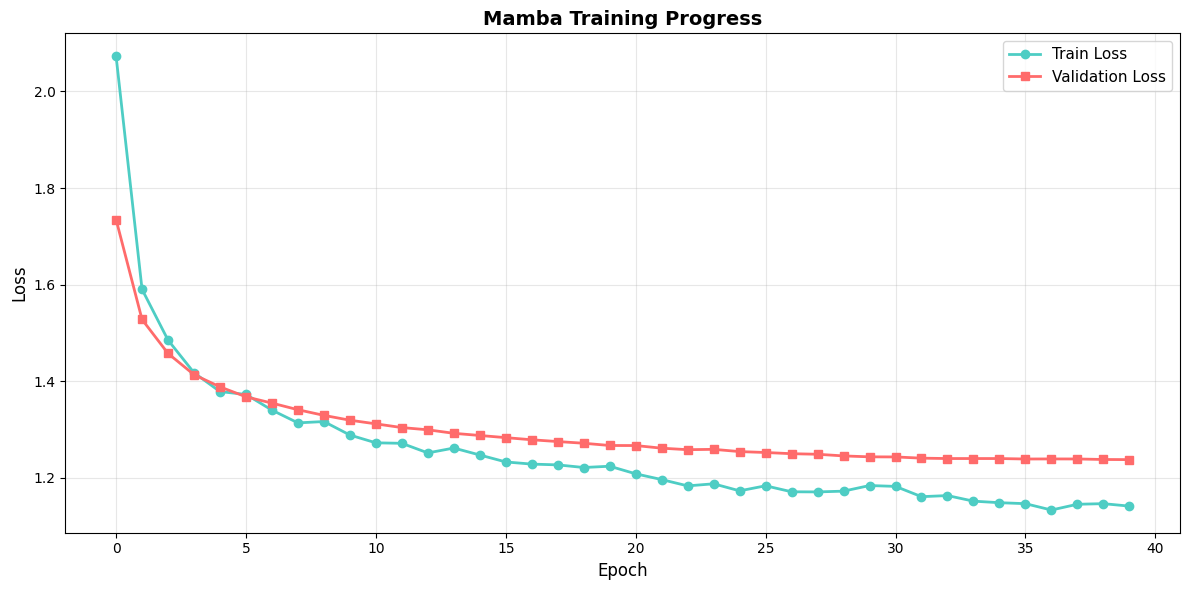

Best validation loss: 1.2375 at epoch 39
Final train loss: 1.1413
Final val loss: 1.2375


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read metrics from CSV logger
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Aggregate by epoch
train_metrics = metrics[["epoch", "train_loss"]].dropna()
val_metrics = metrics[["epoch", "val_loss"]].dropna()
train_metrics = train_metrics.groupby("epoch").mean().reset_index()
val_metrics = val_metrics.groupby("epoch").mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    train_metrics["epoch"],
    train_metrics["train_loss"],
    label="Train Loss",
    marker="o",
    linewidth=2,
    color="#4ECDC4",
)
plt.plot(
    val_metrics["epoch"],
    val_metrics["val_loss"],
    label="Validation Loss",
    marker="s",
    linewidth=2,
    color="#FF6B6B",
)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Mamba Training Progress", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report statistics
best_val_loss = val_metrics["val_loss"].min()
best_epoch = val_metrics.loc[val_metrics["val_loss"].idxmin(), "epoch"]
print(f"Best validation loss: {best_val_loss:.4f} at epoch {int(best_epoch)}")
print(f"Final train loss: {train_metrics['train_loss'].iloc[-1]:.4f}")
print(f"Final val loss: {val_metrics['val_loss'].iloc[-1]:.4f}")

## 8. Text Generation

Test the trained model by generating text continuations.

In [17]:
import time
import torch
import torch.nn.functional as F

def generate(model, prompt, max_len=100, temperature=1.0):
    """
    Generate text continuation from a prompt.
    
    Args:
        model: The trained model
        prompt: Starting text
        max_len: Maximum total length
        temperature: Sampling temperature (lower = more conservative)
    """
    # Ensure model is on the correct device and in eval mode
    device = torch.device(CONFIG["device"])
    model = model.to(device)
    model.eval()

    tokens = tokenizer.encode(prompt)
    max_new = max_len - len(tokens)

    print(prompt, end="", flush=True)

    def sample(logits):
        logits = logits[:, -1] / temperature
        probs = F.softmax(logits, dim=-1)
        return torch.multinomial(probs, 1).item()

    start_time = time.perf_counter()
    generated = 0

    with torch.no_grad():
        for _ in range(max_new):
            # Convert current tokens to tensor
            x = torch.tensor([tokens], device=device)
            
            # Get logits from model
            logits = model(x)
            
            # Sample next token
            t = sample(logits)
            tokens.append(t)
            generated += 1
            print(tokenizer.decode([t]), end="", flush=True)

    elapsed = time.perf_counter() - start_time
    tps = generated / elapsed if elapsed > 0 else 0.0

    print(f"\n\nGenerated {generated} tokens in {elapsed:.2f}s ({tps:.2f} tokens/sec)")

print("Generation function ready!")

Generation function ready!


### Generate Samples

Try different prompts and temperatures to see what the model learned.

In [18]:
print("Sample 1 (temperature=1.0):")
generate(model, "frodo picked up the ", max_len=100, temperature=1.0)

print("\nSample 2 (temperature=1.0):")
generate(model, "gandalf said ", max_len=100, temperature=1.0)

print("\nSample 3 (temperature=0.7 - more focused):")
generate(model, "the ring of power ", max_len=100, temperature=0.7)

Sample 1 (temperature=1.0):
frodo picked up the king alone,  and up no answer e hope be laid 
under the end of the hill. and if 

Generated 80 tokens in 0.37s (216.51 tokens/sec)

Sample 2 (temperature=1.0):
gandalf said that not 
crossed  at  the  lady  knew  at  the  dike,  as  he  hunted  s  above  them,

Generated 87 tokens in 0.24s (356.86 tokens/sec)

Sample 3 (temperature=0.7 - more focused):
the ring of power and the other 
race, and they peered out of the night that they had  brought to ca

Generated 82 tokens in 0.17s (491.42 tokens/sec)


## 9. Key Takeaways

### What We Accomplished

We built the **exact same Mamba model** as the detailed introduction, but with:
- **~60% fewer cells** (15 vs 65 cells)
- **Modern best practices** (HuggingFace datasets, PyTorch Lightning)
- **Focus on what matters**: The Mamba implementation itself

### The Core Mamba Code

Only ~150 lines of code in 3 classes:
1. **MambaBlock**: Selective SSM with data-dependent parameters (B, C, Δ)
2. **ResidualMambaBlock**: Normalization + residual connections
3. **Mamba**: Stack layers and add embeddings

### What Libraries Handled

**Custom CharacterTokenizer** (~40 lines):
- Transformers-compatible interface (encode, decode, __call__)
- Easy to swap with any HuggingFace PreTrainedTokenizer
- Uses "input_ids" key to match HuggingFace conventions

**HuggingFace Datasets** (~3 cells vs ~20 cells):
- Data loading and tokenization
- Train/validation splitting
- Batching and shuffling

**PyTorch Lightning** (~2 cells vs ~15 cells):
- Device management
- Training/validation loops
- Progress bars and logging
- Early stopping
- Checkpointing

### Swapping Tokenizers

To use a different tokenizer, simply replace:
```python
tokenizer = CharacterTokenizer(text)
```

With any HuggingFace tokenizer:
```python
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
```

The rest of the code remains unchanged!

### The Selective SSM Mechanism

The key innovation in Mamba:
1. **Input-dependent parameters**: B, C, Δ computed from input
2. **Discretization**: Convert continuous SSM to discrete time steps
3. **Selective scan**: Recurrent computation with changing parameters
4. **Linear complexity**: O(T) vs O(T²) for Transformers

### Next Steps

To deepen your understanding:
1. **Compare notebooks**: Read the detailed version to understand SSM theory
2. **Modify the config**: Try different state sizes, expand factors, etc.
3. **Visualize parameters**: Plot the learned Δ, B, C values
4. **Swap tokenizers**: Try GPT2Tokenizer or other HuggingFace tokenizers
5. **Scale up**: Increase model size and training data
6. **Try other tasks**: Apply Mamba to different sequence modeling problems

### Why This Matters

Mamba shows that:
- **Selectivity** (content-based parameter adjustment) is powerful
- **Linear complexity** doesn't sacrifice expressiveness
- **Classic control theory** can inspire modern deep learning

The minimal boilerplate approach lets you focus on these core insights instead of data pipelines and training loops!